In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pyddm

import logging
logging.getLogger("pyddm").setLevel(logging.ERROR)   # hide PyDDM's rounding warnings


color1 = '#619dff'
color2 = '#f9766e'
color3 = '#01ba38'

# Global parameters for the analysis
RT_MIN = 0.25
RT_MAX = 1.5
SEED = 0  

# Importing, exploring, and cleaning data

In [2]:
df = pd.read_csv("dataset-2.tsv", sep="\t")

print(f"Trials before trimming: {len(df)}")

# choice: 1 = answered "positive", 0 = answered "negative". Replaces the text column R. PyDDM needs numbers,
df["choice"] = (df["R"] == "positive").astype(int)
df = df.drop(columns="R")

# correct = 1 when the answer matches the word
df["correct"] = ((df["S"] == "positive") == (df["choice"] == 1)).astype(int)
# compatible = in-group face + positive word, or out-group face + negative word
compatible = ((df["picture"] == "ingroup") & (df["S"] == "positive")) | ((df["picture"] == "outgroup") & (df["S"] == "negative"))
df["condition"] = np.where(compatible, "compatible", "incompatible")   # np.where(test, if true, if false)
subjects = sorted(df["subjects"].unique())

# Number and types of trials per subject
for s in subjects:
    d = df[df["subjects"] == s]
    print(f"Subject {s}: {len(d)} trials ({d['condition'].value_counts()['compatible']} compatible, {len(d) - d['condition'].value_counts()['compatible']} incompatible)")

# Drop outlying RTs
df = df[(df["rt"] > RT_MIN) & (df["rt"] < RT_MAX)]
print(f"\nTrials after trimming: {len(df)}")

print(f"Number of subjects: {len(subjects)}")
print(df["condition"].value_counts())

Trials before trimming: 5520
Subject 1: 460 trials (230 compatible, 230 incompatible)
Subject 2: 460 trials (230 compatible, 230 incompatible)
Subject 3: 460 trials (230 compatible, 230 incompatible)
Subject 4: 460 trials (230 compatible, 230 incompatible)
Subject 5: 460 trials (230 compatible, 230 incompatible)
Subject 6: 460 trials (230 compatible, 230 incompatible)
Subject 7: 460 trials (230 compatible, 230 incompatible)
Subject 8: 460 trials (230 compatible, 230 incompatible)
Subject 9: 460 trials (230 compatible, 230 incompatible)
Subject 10: 460 trials (230 compatible, 230 incompatible)
Subject 11: 460 trials (230 compatible, 230 incompatible)
Subject 12: 460 trials (230 compatible, 230 incompatible)

Trials after trimming: 5504
Number of subjects: 12
condition
incompatible    2752
compatible      2752
Name: count, dtype: int64


# Calculate Mean RT and accuracy per subject

          mean RT (s)  accuracy
subjects                       
1               0.651     0.745
2               0.621     0.737
3               0.463     0.761
4               0.493     0.709
5               0.573     0.654
6               0.460     0.751
7               0.495     0.652
8               0.565     0.750
9               0.592     0.654
10              0.564     0.750
11              0.716     0.712
12              0.509     0.820


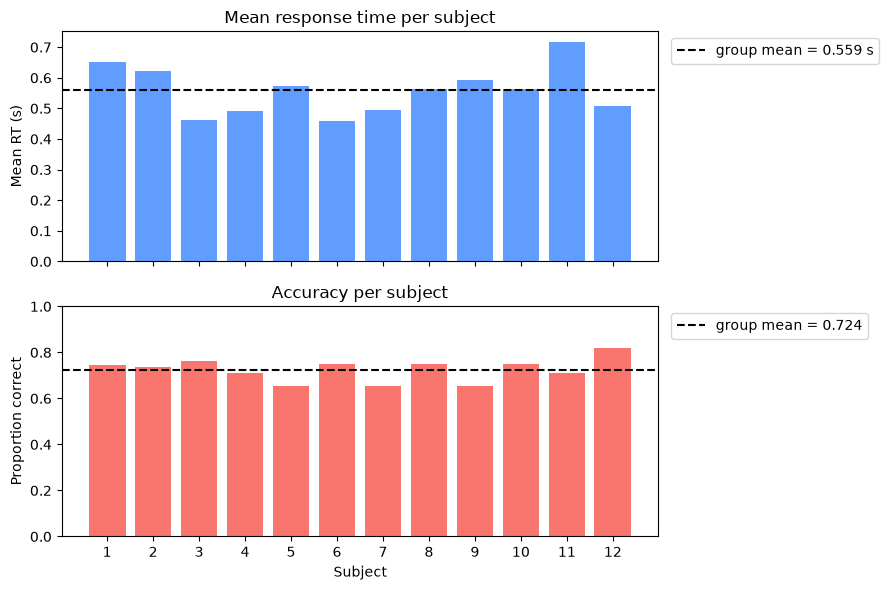

In [3]:
means = df.groupby("subjects")["rt"].mean()
accs = df.groupby("subjects")["correct"].mean()
print(pd.DataFrame({"mean RT (s)": means, "accuracy": accs}).round(3))

labels = [str(s) for s in subjects]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.bar(labels, means, color=color1)
ax1.axhline(np.mean(means), color="k", ls="--", label=f"group mean = {np.mean(means):.3f} s")
ax1.set_title("Mean response time per subject")
ax1.set_ylabel("Mean RT (s)")
ax1.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

ax2.bar(labels, accs, color=color2)
ax2.axhline(np.mean(accs), color="k", ls="--", label=f"group mean = {np.mean(accs):.3f}")
ax2.set_ylim(0, 1)
ax2.set_title("Accuracy per subject")
ax2.set_xlabel("Subject")
ax2.set_ylabel("Proportion correct")
ax2.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

plt.tight_layout()

# Are people more accurate on compatible trials?

condition  compatible  incompatible
subjects                           
1            0.755459      0.733624
2            0.743478      0.730435
3            0.742222      0.778761
4            0.839130      0.578261
5            0.726087      0.582609
6            0.855895      0.646288
7            0.760870      0.543478
8            0.813043      0.686957
9            0.795652      0.510917
10           0.847826      0.652174
11           0.755459      0.668122
12           0.860870      0.778261

Means:
condition
compatible      0.791333
incompatible    0.657491
dtype: float64

 Paired t-test: t(11) = 4.50, p = 0.0009


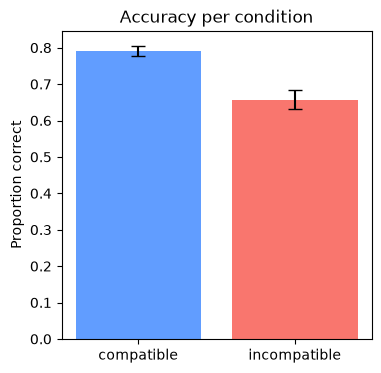

In [4]:
acc = df.groupby(["subjects", "condition"])["correct"].mean().unstack() # create table for comparisons
print(acc)
print(f"\nMeans:")
print(acc.mean())
t = stats.ttest_rel(acc["compatible"], acc["incompatible"])   # paired t-test: same subjects in both conditions
print(f"\n Paired t-test: t({len(acc) - 1}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

plt.figure(figsize=(4, 4))
plt.bar(["compatible", "incompatible"], acc.mean(), yerr=acc.sem(), capsize=5, color=[color1, color2])
plt.ylabel("Proportion correct")
plt.title("Accuracy per condition")
plt.show()

Accuracy 13.4 percentage points higher on compatible trials, on average Paired t-test: t(11) = 4.50, p = 0.0009 -> very strong evidence

# Are correct responses faster on compatible trials?

condition  compatible  incompatible
subjects                           
1            0.663230      0.646547
2            0.601287      0.631340
3            0.450843      0.472722
4            0.468331      0.547374
5            0.554074      0.612567
6            0.433228      0.491054
7            0.455277      0.557607
8            0.539112      0.602820
9            0.581056      0.640108
10           0.531051      0.612632
11           0.717996      0.711581
12           0.498673      0.535661

Means:
condition
compatible      0.541180
incompatible    0.588501
dtype: float64

 Paired t-test: t(11) = -4.61, p = 0.0007


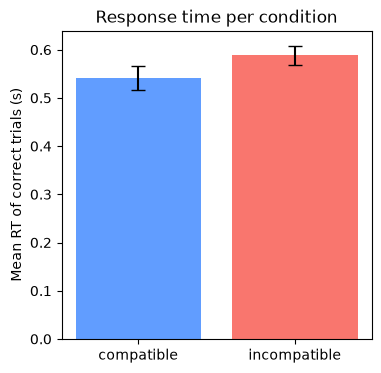

In [5]:
#Same for RTs, but only for correct trials 
rt = df[df["correct"] == 1].groupby(["subjects", "condition"])["rt"].mean().unstack()
print(rt)
print(f"\nMeans:")
print(rt.mean())
t = stats.ttest_rel(rt["compatible"], rt["incompatible"]) 
print(f"\n Paired t-test: t({len(rt) - 1}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

plt.figure(figsize=(4, 4))
plt.bar(["compatible", "incompatible"], rt.mean(), yerr=rt.sem(), capsize=5, color=[color1, color2])
plt.ylabel("Mean RT of correct trials (s)")
plt.title("Response time per condition")
plt.show()

Compatible trials were 47 ms faster on average Paired t-test: t(11) = -4.61, p = 0.0007 -> very strong evidence

# Do the RT distributions differ between conditions?

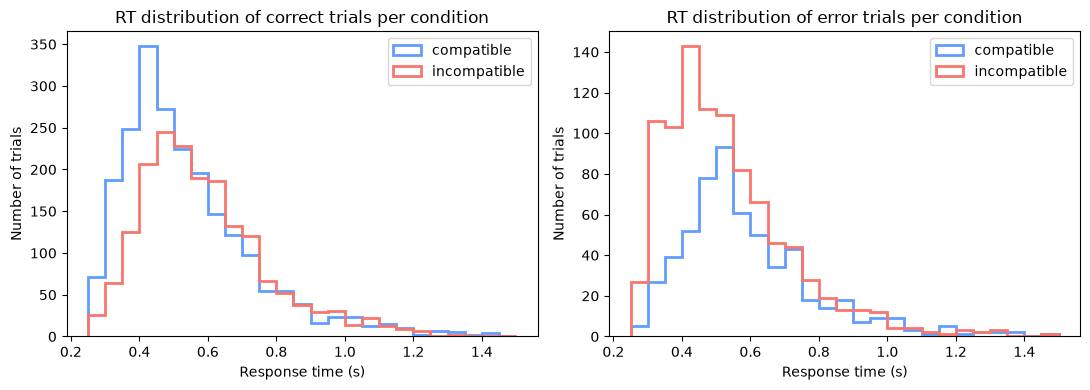

Pooled over all subjects (RT in seconds):
                      count   mean  median    std
correct condition                                
0       compatible      574  0.592   0.547  0.195
        incompatible    943  0.530   0.490  0.184
1       compatible     2178  0.539   0.492  0.193
        incompatible   1809  0.587   0.551  0.185

Correct trials, per-subject means (12 subjects):
  compatible = 0.541 s, incompatible = 0.589 s, difference = -47 ms
  paired t-test: t(11) = -4.61, p = 0.0007

Error trials, per-subject means (12 subjects):
  compatible = 0.584 s, incompatible = 0.533 s, difference = 51 ms
  paired t-test: t(11) = 4.21, p = 0.0015

Error RT minus correct RT: 
(negative = errors are faster)
  compatible: 43 ms, t(11) = 3.96, p = 0.0022
  incompatible: -56 ms, t(11) = -5.06, p = 0.0004


In [6]:
bins = np.arange(RT_MIN, RT_MAX + 0.05, 0.05)    # 50 ms bins over the RTs we kept
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, outcome, name in [(axes[0], 1, "correct"), (axes[1], 0, "error")]:
    for cond, col in [("compatible", color1), ("incompatible", color2)]:
        rts = df[(df["condition"] == cond) & (df["correct"] == outcome)]["rt"]
        ax.hist(rts, bins=bins, histtype="step", lw=2, color=col, label=cond)
    ax.set_xlabel("Response time (s)")
    ax.set_ylabel("Number of trials")
    ax.set_title(f"RT distribution of {name} trials per condition")
    ax.legend()
plt.tight_layout()
plt.show()

# Data, pooled over all subjects
summary = df.groupby(["correct", "condition"])["rt"].agg(["count", "mean", "median", "std"])
print("Pooled over all subjects (RT in seconds):")
print(summary.round(3))

# Per-subject means of correct and error trials, separated by compatibility
for outcome, name in [(1, "correct"), (0, "error")]:
    # one row per subject, one column per condition; .dropna() removes subjects with no trials of this kind
    per_sub = df[df["correct"] == outcome].groupby(["subjects", "condition"])["rt"].mean().unstack().dropna()
    t = stats.ttest_rel(per_sub["compatible"], per_sub["incompatible"])
    diff = per_sub["compatible"] - per_sub["incompatible"]
    print(f"\n{name.capitalize()} trials, per-subject means ({len(per_sub)} subjects):")
    print(f"  compatible = {per_sub['compatible'].mean():.3f} s, incompatible = {per_sub['incompatible'].mean():.3f} s, "
          f"difference = {diff.mean()*1000:.0f} ms")
    print(f"  paired t-test: t({len(per_sub)-1}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

# Speed of errors compared to correct responses?
err = df[df["correct"] == 0].groupby(["subjects", "condition"])["rt"].mean().unstack()
cor = df[df["correct"] == 1].groupby(["subjects", "condition"])["rt"].mean().unstack()
d = (err - cor).dropna()
print("\nError RT minus correct RT: \n(negative = errors are faster)")
for cond in ["compatible", "incompatible"]:
    t = stats.ttest_1samp(d[cond], 0)
    print(f"  {cond}: {d[cond].mean()*1000:.0f} ms, t({len(d)-1}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

There are significantly more errors in the incompatible trials of our dataset. Also that correct responses are faster on compatible trials, and errors are faster on incompatible trials.

These observations, in combination with the existent studies, led to our proposed research question.

In [7]:
# Drift rate: positive words push towards positive
def drift(S, v_pos, v_neg):
    if S == "positive":
        return v_pos
    else:
        return -v_neg

# Starting point: depends on which face was shown (0 = middle, no bias)
def starting_point(picture, x0_in, x0_out):
    if picture == "ingroup":
        return x0_in
    else:
        return x0_out

# Model 2: starting point shifts with the face, drift rate is constant
m_start = pyddm.gddm(
    drift=drift,
    starting_position=starting_point,
    noise=1,
    bound="B",
    nondecision="ndt",
    parameters={"v_pos": (0, 5), "v_neg": (0, 5), "B": (0.3, 2),
                "x0_in": (-0.8, 0.8), "x0_out": (-0.8, 0.8), "ndt": (0, 0.5)},
    conditions=["S", "picture"],
    choice_names=("positive", "negative"),
    T_dur=RT_MAX)

In [8]:
# Fit the model to each subject separately
rows = []
for s in subjects:
    d = df[df["subjects"] == s]
    sample = pyddm.Sample.from_pandas_dataframe(d, rt_column_name="rt", choice_column_name="choice",
                                                choice_names=("positive", "negative"))
    m_start.fit(sample, verbose=False, fitparams={"seed": SEED})   # seed: same result every run
    rows.append(m_start.get_model_parameters())
    print(f"Subject {s} done")

# One row per subject, one column per parameter
fits = pd.DataFrame(rows, index=subjects, columns=m_start.get_model_parameter_names()).astype(float)
fits.index.name = "subject"
print(fits.round(3))

Subject 1 done
Subject 2 done
Subject 3 done
Subject 4 done
Subject 5 done
Subject 6 done
Subject 7 done
Subject 8 done
Subject 9 done
Subject 10 done
Subject 11 done
Subject 12 done
         v_pos  v_neg      B  x0_in  x0_out  nondectime
subject                                                
1        1.155  1.076  0.492  0.061   0.009       0.432
2        1.133  0.995  0.501  0.040  -0.056       0.391
3        1.222  1.079  0.516  0.019  -0.070       0.220
4        1.114  0.877  0.514  0.265  -0.349       0.271
5        0.776  0.595  0.494  0.239  -0.171       0.347
6        1.287  1.165  0.484  0.159  -0.218       0.256
7        0.933  0.492  0.484  0.218  -0.356       0.282
8        1.000  1.321  0.485  0.152  -0.191       0.354
9        1.078  0.377  0.482  0.169  -0.332       0.389
10       1.340  1.122  0.489  0.210  -0.273       0.361
11       0.926  0.929  0.501  0.044  -0.085       0.482
12       1.391  1.790  0.503  0.187  -0.058       0.302


# Tests

In [9]:
def print_t(label, t):
    print(f"{label}: t({t.df}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

print_t("H1a: in-group face shifts the start (x0_in vs 0)", stats.ttest_1samp(fits["x0_in"], 0))
print_t("H1b: out-group face shifts the start (x0_out vs 0)", stats.ttest_1samp(fits["x0_out"], 0))
print_t("Faces differ (x0_in vs x0_out)", stats.ttest_rel(fits["x0_in"], fits["x0_out"]))
# x0_in + x0_out = (in-group shift) - (out-group shift); 0 means both shifts are equally large
print_t("H2: one shift is bigger (x0_in + x0_out vs 0)", stats.ttest_1samp(fits["x0_in"] + fits["x0_out"], 0))

# The same starting points on the 0-1 scale from the Introduction (0.5 = middle)
print("mean z_in: ", ((fits["x0_in"] + 1) / 2).mean().round(3))
print("mean z_out:", ((fits["x0_out"] + 1) / 2).mean().round(3))

H1a: in-group face shifts the start (x0_in vs 0): t(11) = 5.99, p = 0.0001
H1b: out-group face shifts the start (x0_out vs 0): t(11) = -4.86, p = 0.0005
Faces differ (x0_in vs x0_out): t(11) = 5.65, p = 0.0001
H2: one shift is bigger (x0_in + x0_out vs 0): t(11) = -1.31, p = 0.2158
mean z_in:  0.573
mean z_out: 0.41


H1 is supported: both faces shift the starting point. the two starting points differ clearly from each other. Same result Todd et al. (2021) reported as a Black-vs-White difference.

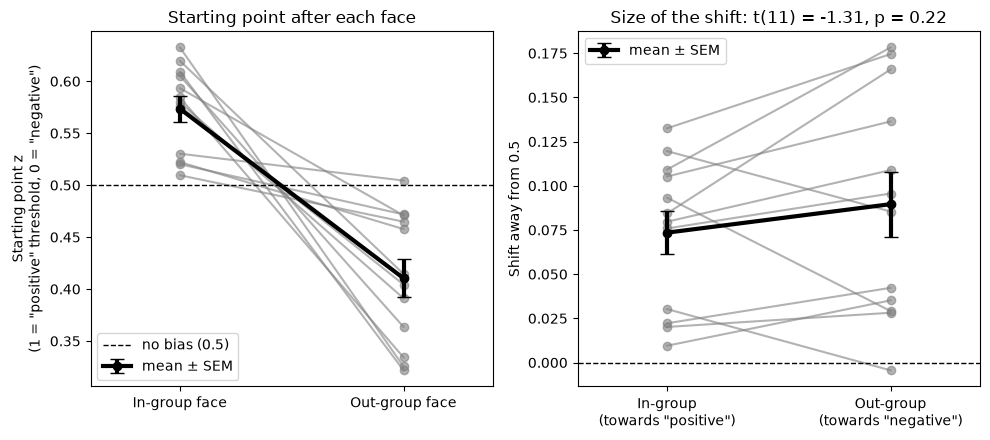

In [10]:
# Starting points on the 0-1 scale (0.5 = no bias)
z_in = (fits["x0_in"] + 1) / 2
z_out = (fits["x0_out"] + 1) / 2

# Size of each shift away from the middle
shift_in = z_in - 0.5      # towards "positive"
shift_out = 0.5 - z_out    # towards "negative"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: where the decision starts after each face (H1)
for s in subjects:
    ax1.plot([0, 1], [z_in[s], z_out[s]], color="grey", alpha=0.6, marker="o")   # one line per subject
ax1.errorbar([0, 1], [z_in.mean(), z_out.mean()], yerr=[z_in.sem(), z_out.sem()],
             color="k", lw=3, marker="o", capsize=5, label="mean ± SEM")
ax1.axhline(0.5, color="k", ls="--", lw=1, label="no bias (0.5)")
ax1.set_xticks([0, 1], ["In-group face", "Out-group face"])
ax1.set_xlim(-0.4, 1.4)
ax1.set_ylabel('Starting point z\n(1 = "positive" threshold, 0 = "negative")')
ax1.set_title("Starting point after each face")
ax1.legend(loc="lower left")

# Right: how far each face moves the start from the middle (H2)
for s in subjects:
    ax2.plot([0, 1], [shift_in[s], shift_out[s]], color="grey", alpha=0.6, marker="o")
ax2.errorbar([0, 1], [shift_in.mean(), shift_out.mean()], yerr=[shift_in.sem(), shift_out.sem()],
             color="k", lw=3, marker="o", capsize=5, label="mean ± SEM")
ax2.axhline(0, color="k", ls="--", lw=1)
ax2.set_xticks([0, 1], ['In-group\n(towards "positive")', 'Out-group\n(towards "negative")'])
ax2.set_xlim(-0.4, 1.4)
ax2.set_ylabel("Shift away from 0.5")
t = stats.ttest_rel(shift_in, shift_out)
ax2.set_title(f"Size of the shift: t({len(subjects) - 1}) = {t.statistic:.2f}, p = {t.pvalue:.2f}")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

Fitted starting points per participant (grey lines) and group mean ± SEM (black). Left: starting point after in-group and out-group faces; the dashed line marks no bias (z = 0.5). Right: size of each shift away from 0.5, in the direction of the face's associated valence

Subject 1 done
Subject 2 done
Subject 3 done
Subject 4 done
Subject 5 done
Subject 6 done
Subject 7 done
Subject 8 done
Subject 9 done
Subject 10 done
Subject 11 done
Subject 12 done
         no face effect  face shifts start  face changes drift  \
subject                                                          
1                 -31.2              -25.8               -25.1   
2                  12.9               14.9                18.1   
3                  35.0               38.3                40.7   
4                  65.3              -50.1                31.9   
5                  95.2               45.2                91.0   
6                 -87.3             -133.5              -113.6   
7                  79.6              -13.3                56.8   
8                 -39.8              -76.0               -49.0   
9                   8.5              -68.7               -26.2   
10                -68.5             -137.7               -94.5   
11                 60.5  

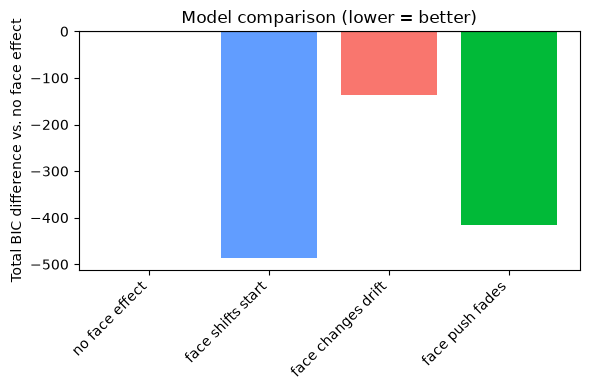

In [11]:
# Model 1: the face does not affect the drift or starting point. Neutral starting point.
m_none = pyddm.gddm(
    drift=drift,
    starting_position="x0",
    noise=1,
    bound="B",
    nondecision="ndt",
    parameters={"v_pos": (0, 5), "v_neg": (0, 5), "B": (0.3, 2),
                "x0": (-0.8, 0.8), "ndt": (0, 0.5)},
    conditions=["S", "picture"],
    choice_names=("positive", "negative"),
    T_dur=RT_MAX)

# Model 3: the face changes the drift instead of the starting point
def drift_face(S, picture, v_pos, v_neg, v_face):
    # the word pushes the current value up or down, as before
    if S == "positive":
        v = v_pos
    else:
        v = -v_neg
    # the face adds an extra push: up after in-group faces, down after out-group faces
    if picture == "ingroup":
        return v + v_face
    else:
        return v - v_face

m_drift = pyddm.gddm(
    drift=drift_face,
    starting_position="x0",
    noise=1,
    bound="B",
    nondecision="ndt",
    parameters={"v_pos": (0, 5), "v_neg": (0, 5), "v_face": (-2, 2), "B": (0.3, 2),
                "x0": (-0.8, 0.8), "ndt": (0, 0.5)},
    conditions=["S", "picture"],
    choice_names=("positive", "negative"),
    T_dur=RT_MAX)

# Model 4: the face gives a push that fades over time
def drift_face_decay(S, picture, t, v_pos, v_neg, v_face, tau):
    if S == "positive":
        v = v_pos
    else:
        v = -v_neg
    # the face's push is strongest at the start and fades away; tau = how quickly (in seconds)
    push = v_face * np.exp(-t / tau)
    if picture == "ingroup":
        return v + push
    else:
        return v - push

m_decay = pyddm.gddm(
    drift=drift_face_decay,
    starting_position="x0",
    noise=1,
    bound="B",
    nondecision="ndt",
    parameters={"v_pos": (0, 5), "v_neg": (0, 5), "v_face": (-10, 10), "tau": (0.01, 1),
                "B": (0.3, 2), "x0": (-0.8, 0.8), "ndt": (0, 0.5)},
    conditions=["S", "picture"],
    choice_names=("positive", "negative"),
    T_dur=RT_MAX)


# Load the 4 models for comparison
models = {"no face effect": m_none, "face shifts start": m_start, "face changes drift": m_drift, "face push fades": m_decay}
taus = []    # fade time of the face push, per subject
# Fit every model to every subject and compute its BIC (lower = better)
rows = []
for s in subjects:
    d = df[df["subjects"] == s]
    sample = pyddm.Sample.from_pandas_dataframe(d, rt_column_name="rt", choice_column_name="choice", choice_names=("positive", "negative"))
    row = {}
    for name, model in models.items():
        model.fit(sample, verbose=False, fitparams={"seed": SEED})
        nll = model.fitresult.value()  # how badly the model fits (lower = better)
        k = len(model.get_model_parameters())  # number of free parameters
        row[name] = 2 * nll + k * np.log(len(d))  # BIC: fit + penalty for extra parameters
    rows.append(row)
    taus.append(m_decay.get_model_parameters()[3])   # tau is the 4th parameter; m_decay was fitted last
    print(f"Subject {s} done")


bic = pd.DataFrame(rows, index=subjects)
bic.index.name = "subject"
print(bic.round(1)) # print the BIC of each model for each subject, rounded to 1 decimal place

print(f"\ntau per subject (s):", np.round(taus, 3))

# Summary: total BIC over all subjects, and how often each model wins
print("\nTotal BIC (lower = better):")
print(bic.sum().round(1))
print("\nBest model per subject:")
# for each subject: the model with the lowest BIC, then count how often each model wins
print(bic.idxmin(axis=1).value_counts())
# Total BIC of each model minus the total BIC of "no face effect" (below 0 = better)
total = bic.sum()
plt.figure(figsize=(6, 4))
plt.bar(total.index, total - total["no face effect"], color=["#FF00EE", color1, color2, color3])
plt.axhline(0, color="k", lw=0.8)
plt.ylabel("Total BIC difference vs. no face effect")
plt.title("Model comparison (lower = better)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The starting-point model wins overall. It also beats both drift models in all 12 subjects The starting-point model was preferred for 8 of 12 participants; for the remaining four, who showed the smallest starting-point shifts, the model without a face effect was preferred by a small margin ($\Delta$ BIC < 6).

BIC (Bayesian Information Criterion) gives each model one score that combines two things: how well it fits the data, and how many adjustable parameters it needed to get that fit. Lower is better.

The fading push fades almost immediately. $\tau$ ranges from 11 to 41 ms across subjects, close to the lower limit of 10 ms. A lower value for $\tau$ means that the push is applied within fewer timesteps and fades quickly A push that brief is practically the same as starting the current value off-centre, imitating the starting-point model. It loses in the BIC comparison however because it uses an extra parameter

                    real  model
picture  S                     
ingroup  negative  0.657  0.661
         positive  0.800  0.800
outgroup negative  0.783  0.795
         positive  0.657  0.659


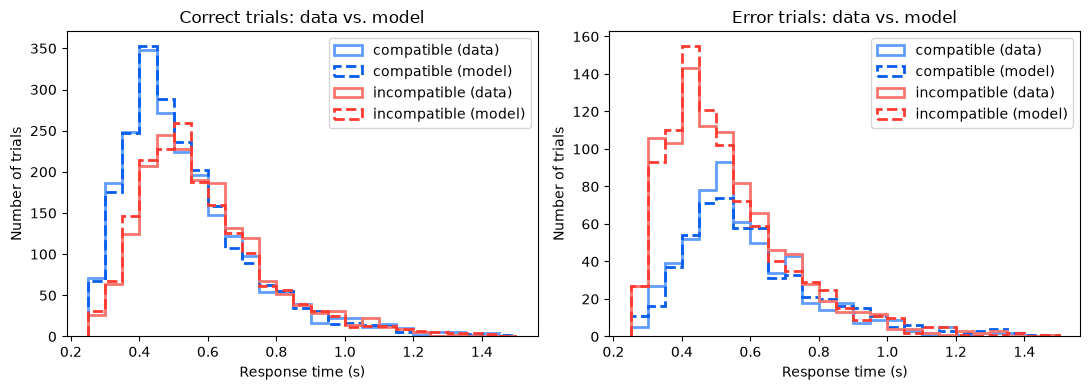

In [12]:
# For each subject: put their fitted values back into the model and simulate a fake experiment
sim_parts = []
for s in subjects:
    m_start.set_model_parameters(fits.loc[s].values)
    d = df[df["subjects"] == s]
    # simulate as many trials as the subject really did, for each word/face combination
    for word in ["positive", "negative"]:
        for face in ["ingroup", "outgroup"]:
            n = len(d[(d["S"] == word) & (d["picture"] == face)]) # number of real trials of this kind
            solution = m_start.solve(conditions={"S": word, "picture": face})   # the model's prediction
            sim = solution.sample(n, seed=SEED + len(sim_parts)).to_pandas_dataframe(rt_column_name="rt", choice_column_name="choice")  # n fake trials; a new seed for every batch            
            sim["S"] = word
            sim["picture"] = face
            sim["subjects"] = s
            sim_parts.append(sim)

# Combine and add the same columns as the real data
sim = pd.concat(sim_parts) 
sim = sim.dropna()  # fake trials with no answer before RT_MAX
sim = sim[(sim["rt"] > RT_MIN) & (sim["rt"] < RT_MAX)] # same trimming as the real data
# same columns as the real data
sim["correct"] = ((sim["S"] == "positive") == (sim["choice"] == 1)).astype(int)
compatible = ((sim["picture"] == "ingroup") & (sim["S"] == "positive")) | ((sim["picture"] == "outgroup") & (sim["S"] == "negative"))
sim["condition"] = np.where(compatible, "compatible", "incompatible") 


# Accuracy comparison over face/word combinations
acc_real = df.groupby(["picture", "S"])["correct"].mean()
acc_sim = sim.groupby(["picture", "S"])["correct"].mean()
print(pd.DataFrame({"real": acc_real, "model": acc_sim}).round(3))

# RT distribution plots: real (solid) vs. model (dashed, saturated), for correct and error trials
bins = np.arange(RT_MIN, RT_MAX + 0.05, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, outcome, name in [(axes[0], 1, "correct"), (axes[1], 0, "error")]:
    for cond, main_col, sec_col in [("compatible", color1, "#055dec"), ("incompatible", color2, "#ff3a30")]:
        real_rts = df[(df["condition"] == cond) & (df["correct"] == outcome)]["rt"]
        sim_rts = sim[(sim["condition"] == cond) & (sim["correct"] == outcome)]["rt"]
        ax.hist(real_rts, bins=bins, histtype="step", lw=2, color=main_col, label=f"{cond} (data)")
        ax.hist(sim_rts, bins=bins, histtype="step", lw=2, ls="--", color=sec_col, label=f"{cond} (model)")
    ax.set_xlabel("Response time (s)")
    ax.set_ylabel("Number of trials")
    ax.set_title(f"{name.capitalize()} trials: data vs. model")
    ax.legend()
plt.tight_layout()
plt.show()

Data simulated from each participant's fitted parameters closely matched the observed accuracies (within 1.1 percentage points in every face × word condition) and the RT distributions of correct and error responses, including the fast errors on incompatible trials.